1. Use the question/target variable you submitted and 
build a model to answer the question you created for this dataset (make sure it is a classification problem, convert if necessary). 

2. Build a kNN model to predict your target variable using 3 nearest neighbors. Make sure it is a classification problem, meaning
if needed changed the target variable.

3. Create a dataframe that includes the test target values, test predicted values, 
and test probabilities of the positive class.

4. No code question: If you adjusted the k hyperparameter what do you think would
happen to the threshold function? Would the confusion look the same at the same threshold 
levels or not? Why or why not?

5. Evaluate the results using the confusion matrix. Then "walk" through your question, summarize what 
concerns or positive elements do you have about the model as it relates to your question? 

6. Create two functions: One that cleans the data & splits into training|test and one that 
allows you to train and test the model with different k and threshold values, then use them to 
optimize your model (test your model with several k and threshold combinations). Try not to use variable names 
in the functions, but if you need to that's fine. (If you can't get the k function and threshold function to work in one
function just run them separately.) 

7. How well does the model perform? Did the interaction of the adjusted thresholds and k values help the model? Why or why not? 

8. Choose another variable as the target in the dataset and create another kNN model using the two functions you created in
step 7. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("https://github.com/UVADS/DS-3021/raw/main/data/cc_institution_details.csv")

### Cleaning Data

### 1. Use the question/target variable you submitted and build a model to answer the question you created for this dataset. 

Question: Can we predict how much money schools spend on awards from public information?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   index                                 3798 non-null   int64  
 1   unitid                                3798 non-null   int64  
 2   chronname                             3798 non-null   object 
 3   city                                  3798 non-null   object 
 4   state                                 3798 non-null   object 
 5   level                                 3798 non-null   object 
 6   control                               3798 non-null   object 
 7   basic                                 3798 non-null   object 
 8   hbcu                                  94 non-null     object 
 9   flagship                              50 non-null     object 
 10  long_x                                3798 non-null   float64
 11  lat_y            

In [4]:
def college_data_prep(data):
    # Filtering to keep only values we need, dropping NA vals
    college_data_filtered = data[['chronname', 'level', 'control', 'student_count', 'grad_100_percentile',
                                       'ft_pct', 'exp_award_value', 'awards_per_value']]
    college_data_filtered = college_data_filtered.dropna(subset=['grad_100_percentile', 'ft_pct'])
    # Making object variables categorical
    college_data_filtered['level'] = college_data_filtered['level'].astype('category')
    college_data_filtered['control'] = college_data_filtered['control'].astype('category')
    
    # Making student count categorical
    count_pct = np.percentile(college_data_filtered['student_count'], [25, 50, 75])
    count_25 =  count_pct[0]
    count_50 =  count_pct[1]
    count_75 =  count_pct[2]
    for index, row in college_data_filtered.iterrows():
        if row['student_count'] < count_pct[0]:
            college_data_filtered.at[index, 'student_count'] = 1
        elif row['student_count'] < count_pct[1]:
            college_data_filtered.at[index, 'student_count'] = 2
        elif row['student_count'] < count_pct[2]:
            college_data_filtered.at[index, 'student_count'] = 3
        else:
            college_data_filtered.at[index, 'student_count'] = 4
    college_data_filtered['student_count'] = college_data_filtered['student_count'].astype('category')
    # Defining and adding target variable
    college_data_filtered['award_total'] = college_data_filtered['awards_per_value'] * college_data_filtered['exp_award_value']
    # Standardizing numeric data
    my_list = list(college_data_filtered.select_dtypes(include=['number']))
    college_data_filtered[my_list] = MinMaxScaler().fit_transform(college_data_filtered[my_list])
    # One hot encoding for categorical variables
    category_list = list(college_data_filtered.select_dtypes('category'))
    college_data_filtered_1h = pd.get_dummies(college_data_filtered, columns=category_list, drop_first = True)
    # Redefines target variable as a 0 or 1
    college_data_filtered_1h['award_total'] = pd.cut(college_data_filtered_1h.award_total, bins = [-1,0.106659,1], labels =[0,1])
    # Drop unneeded columns
    college_dt = college_data_filtered_1h.drop(['exp_award_value', 'awards_per_value', 'chronname'], axis=1)
    #Partition data into train, test, tune
    Train, Test = train_test_split(college_dt, train_size=2600, stratify=college_dt.award_total, random_state=42)
    Test, Val = train_test_split(Test,  train_size = .5, stratify= Test.award_total)
    X_train, y_train = Train.drop(columns=['award_total']), Train['award_total']
    X_test, y_test = Test.drop(columns=['award_total']), Test['award_total']
    X_val, y_val = Val.drop(columns=['award_total']), Val['award_total']
    return X_train, y_train, X_test, y_test, X_val, y_val, college_dt

X_train, y_train, X_test, y_test, X_val, y_val, full_data = college_data_prep(df)

### P2

In [6]:
#Training the classifier for k=3
import random
random.seed(1984)   # kNN is a random algorithm, so we use `random.seed(x)` to make results repeatable

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### P3

In [7]:
test_tar = y_test
test_pred = neigh.predict(X_test)
y_prob = neigh.predict_proba(X_test)[:, 1]

output_df = pd.DataFrame({'test_tar': test_tar, 'test_pred': test_pred, 'y_prob': y_prob})
output_df_positive = output_df[output_df['test_tar'] == 1]

output_df_positive

,test_tar,test_pred,y_prob
3196,1,1,0.666667
1532,1,1,1.000000
2579,1,1,1.000000
240,1,1,1.000000
3156,1,0,0.333333
...,...,...,...
2231,1,1,1.000000
2028,1,0,0.000000
1189,1,1,1.000000
625,1,1,1.000000


### P4
When K is changed in the model we are changing the amount of data points we are considering to classify our points into their respective classes. If we alter the k hyperparameter to consider more or less nearest neighbors then the classification will change. The threshold function is what we set to be the percentage of selected nearest neighbors needed for classification and the default is 50%. Suppose we chose a k-value of 3 and the two closest points were positive. If the next 15 closest points were negative, increasing our k-value to anything between 5 and 17 would result in the classification being negative, not positive. When we have a small k value, each neighbor has a higher impact on our classification vs. a larger k-value. Lower k values may lead to a lot of noise in the confusion matrix, but too high of a k-value will under fit our data. 

### P5

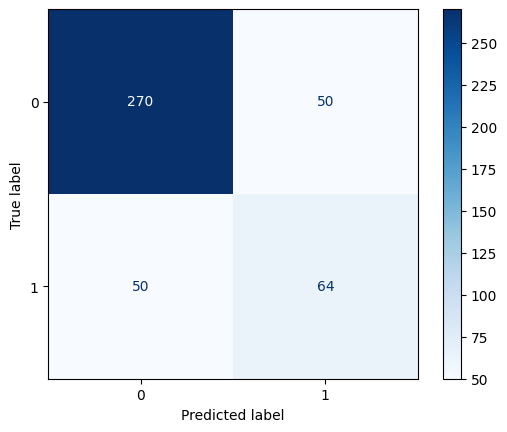

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Make/show confusion matrix
cm = confusion_matrix(y_val, neigh.predict(X_val))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.show()


My question is whether we can predict if college grant high levels/amounts of award money to students based on public information. The confusion matrix shows that a majority of our data is schools that are not considered to give out high amounts of award money and they are properly labeled this way. However, what we are most concerned with is our true positive values. We want to predict that schools will give out a high amount of award money and have it align with strong awards programs. True positives are represented by 66 observations which is not that many. What is most concerning is that we have almost as many false positives as true positives. This is due to only a small amount of our schools being classified as having strong awards programs, but our KNN model is not the strongest at predicting schools with strong award programs. A way to combat this would be to make a higher threshold in order to control for the high amount of false positives

### P6

Cleaning/splitting data(taking variable names out, making them parameters)

In [9]:
def college_data_prep_1(data, varnames, drop_vars, cat_vars, subset_var, target_var, drop_vars_2):
    # Filtering to keep only values we need
    college_data_filtered = data[varnames].copy()

    # Making object variables categorical
    college_data_filtered[cat_vars] = college_data_filtered[cat_vars].astype('category')
    college_data_filtered = college_data_filtered.dropna(subset=drop_vars)

    # Making student count categorical using percentiles
    count_pct = np.percentile(college_data_filtered[subset_var], [25, 50, 75])
    college_data_filtered[subset_var + '_cat'] = pd.cut(
        college_data_filtered[subset_var],
        bins=[0, count_pct[0], count_pct[1], count_pct[2], float('inf')],
        labels=[1, 2, 3, 4],
        include_lowest=True).astype('category')

    # Standardizing numeric data
    numeric_cols = college_data_filtered.select_dtypes(include=['number']).columns
    college_data_filtered[numeric_cols] = MinMaxScaler().fit_transform(college_data_filtered[numeric_cols])

    # One-hot encoding categorical variables
    category_list = college_data_filtered.select_dtypes('category').columns
    college_data_filtered_1h = pd.get_dummies(college_data_filtered, columns=category_list, drop_first=True)

    # Define binary target variable using the *original* student count.
    college_data_filtered_1h[target_var] = pd.cut(
        data[target_var], bins=[0, count_pct[1], float('inf')], labels=[0, 1], include_lowest=True)

    # Drop unneeded columns
    college_dt = college_data_filtered_1h.drop(columns=drop_vars_2)

    # Partition data into train, test, tune
    Train, Test = train_test_split(college_dt, train_size=2600, stratify=college_dt[target_var], random_state=42)
    Test, Val = train_test_split(Test, train_size=0.5, stratify=Test[target_var], random_state=42)

    # Pull out X, Y
    X_train, y_train = Train.drop(columns=target_var), Train[target_var]
    X_test, y_test = Test.drop(columns=target_var), Test[target_var]
    X_val, y_val = Val.drop(columns=target_var), Val[target_var]
    # Made dummy earlier, have to take it out
    X_train = X_train.drop(columns=[col for col in X_train.columns if target_var in col], errors='ignore')
    X_test = X_test.drop(columns=[col for col in X_test.columns if target_var in col], errors='ignore')

    return X_train, y_train, X_test, y_test, X_val, y_val, college_dt

K and threshold functions

In [10]:
def chooseK(k, X_train, y_train, X_test, y_test):    
    random.seed(17)
    class_knn = KNeighborsClassifier(n_neighbors=k)
    class_knn.fit(X_train, y_train)
    
    # calculate accuracy
    accuracy = class_knn.score(X_test, y_test)
    return accuracy

In [11]:
test = pd.DataFrame({'k':list(range(1,22,2)), 
                     'accuracy':[chooseK(x, X_train, y_train, X_test, y_test) for x in list(range(1, 22, 2))]})
test = test.sort_values(by=['accuracy'], ascending=False)
test

,k,accuracy
7,15,0.831409
9,19,0.831409
10,21,0.829099
8,17,0.826790
5,11,0.822171
6,13,0.819861
2,5,0.808314
3,7,0.806005
4,9,0.803695
1,3,0.799076


In [12]:
from sklearn.metrics import accuracy_score

def threshold_optim(k, thresholds, X_train, y_train, X_test, y_test):
    results = [] 

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    pred_probs = knn.predict_proba(X_test)[:, 1]

    for threshold in thresholds:
        y_pred = (pred_probs > threshold).astype(int)
        score = accuracy_score(y_test, y_pred)
        results.append({'threshold': threshold, 'accuracy': score})
    results_df = pd.DataFrame(results)

    return results_df


In [13]:
thresholds = np.linspace(0.1, 0.9, 9)  # Testing threshold from 0.1 to 0.9
results_df = threshold_optim(k=19, thresholds=thresholds, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
results = results_df.sort_values(by=['accuracy'], ascending=False)
results


,threshold,accuracy
4,0.5,0.831409
5,0.6,0.819861
3,0.4,0.817552
6,0.7,0.817552
7,0.8,0.810624
8,0.9,0.787529
2,0.3,0.778291
1,0.2,0.722864
0,0.1,0.598152


### P7

From the above functions and test cases, we see that adjusting the k value does help. We found that considering 15 nearest neighbors(which is a pretty high value) resulted in the optimal outcome. Rather than testing all thresholds for all k values I wanted to find the best k and then find the best threshold. It can be seen that a threshold of 0.5 was the best and we will not need to change it. From this we conclude that we should consider more nearest neighbors.

### P8

Updating to have student count as target variable(question would be does larger universities grant more awards)

In [14]:
df.columns = df.columns.str.strip() 

In [15]:
X_train, y_train, X_test, y_test, X_val, y_val, college_dt = college_data_prep_1(
    data=df, 
    varnames=['chronname', 'level', 'control', 'student_count', 'grad_100_percentile',
              'ft_pct', 'exp_award_value', 'awards_per_value'], 
    drop_vars=['grad_100_percentile', 'ft_pct'], 
    cat_vars=['level', 'control'],
    subset_var='student_count', 
    target_var='student_count', 
    drop_vars_2=['exp_award_value', 'awards_per_value', 'chronname']
)


In [16]:
test_1 = pd.DataFrame({'k':list(range(1,22,2)), 
                     'accuracy':[chooseK(x, X_train, y_train, X_test, y_test) for x in list(range(1, 22, 2))]})
test_1 = test.sort_values(by=['accuracy'], ascending=False)
test_1

,k,accuracy
7,15,0.831409
9,19,0.831409
10,21,0.829099
8,17,0.826790
5,11,0.822171
6,13,0.819861
2,5,0.808314
3,7,0.806005
4,9,0.803695
1,3,0.799076


In [18]:
thresholds = np.linspace(0.1, 0.9, 9)  # Testing threshold from 0.1 to 0.9
results_df_1 = threshold_optim(k=21, thresholds=thresholds, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
results_df_1

,threshold,accuracy
0,0.1,0.709007
1,0.2,0.755196
2,0.3,0.773672
3,0.4,0.796767
4,0.5,0.789838
5,0.6,0.769053
6,0.7,0.750577
7,0.8,0.729792
8,0.9,0.676674


Threshold of 0.4 and k val of 15 are best.